# Smoking Cessation Social Media Sentiment Analysis

**NLP and Machine Learning Portfolio Project**

**Author: Swapnik Hazari**

## Project Overview

This project applies natural language processing (NLP), exploratory data analysis, and supervised machine learning to examine sentiment patterns in public social-media discussions related to smoking cessation.

The analytical sample contains 10,000 posts categorized using existing positive, neutral, and negative sentiment labels.

## Research Question

**How can NLP methods characterize sentiment and recurring themes in public smoking-cessation discussions, with particular attention to respiratory-health relevance, engagement patterns, and methodological limitations?**

## Analytical Approach

The analysis includes:

- Data validation and preprocessing
- Exploratory sentiment analysis
- Engagement analysis
- Term-frequency analysis
- TF-IDF feature engineering
- Logistic Regression classification
- Multinomial Naive Bayes classification
- Precision, recall, F1-score, and confusion-matrix evaluation
- Error analysis
- Model interpretability
- Exploratory public-health contextual analysis

> **Data governance:** Raw social-media records and identifiers are not distributed through this repository. Results are presented in aggregate to support responsible use of social-media data.

## 1. Environment and Libraries

The analysis uses Python with pandas and NumPy for data manipulation, Matplotlib for visualization, and scikit-learn for TF-IDF feature engineering, classification, and model evaluation.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Data Loading and Sample Construction

The original source contained **2,821,314 records**. Because the source JSON file was approximately 1.85 GB, streaming processing was used during initial data preparation to avoid loading the complete dataset into memory.

The existing sentiment-label distribution in the full source dataset was:

| Sentiment | Records |
|---|---:|
| Positive | 1,395,004 |
| Neutral | 740,710 |
| Negative | 685,600 |
| **Total** | **2,821,314** |

A stratified sample of 10,000 records was selected while preserving the source sentiment distribution. Data-quality validation confirmed that the 10,000-record analytical sample contained valid sentiment labels and complete values for the variables used in the final analysis.

The raw social-media source and direct identifiers are not redistributed through this repository.

### Stratified Sample Construction

### Stratified Sample Construction

To create a computationally manageable analytical dataset while preserving the source sentiment distribution, a **stratified reservoir-sampling procedure** was used.

The sampling procedure:

1. Streamed the sentiment-label column using `ijson`.
2. Maintained separate reservoirs for positive, neutral, and negative records.
3. Used a fixed random seed (`42`) to support reproducibility.
4. Selected 10,000 records while preserving the source class distribution.
5. Performed a second streaming pass to retrieve the analytical variables associated with the selected row indices.
6. Validated the extracted records before downstream analysis.

The initial stratified sample targeted:

| **Sentiment** | **Target Records** |
| ------------: | -----------------: |
| Positive | 4,945 |
| Neutral | 2,626 |
| Negative | 2,429 |
| **Total** | **10,000** |

Following data-quality validation, the final analytical dataset contained **10,000 records**.

## 3. Data Quality Assessment

The analytical dataset was validated before downstream analysis. Records were checked for valid sentiment labels (`pos`, `neu`, or `neg`) and non-missing post text.

The current validated dataset contains **10,000 observations**:

- **Positive:** 4,945
- **Neutral:** 2,626
- **Negative:** 2,429

The validation code below confirms that all records in the analytical dataframe satisfy the required sentiment-label and text criteria.

In [85]:
valid_labels = ["pos", "neu", "neg"]

initial_rows = len(df)

df = df[
    df["sentiment_label"].isin(valid_labels)
    & df["content"].notna()
].copy()

removed_rows = initial_rows - len(df)

print(f"Initial records: {initial_rows:,}")
print(f"Records removed: {removed_rows:,}")
print(f"Final analytical records: {len(df):,}")

print("\nSentiment distribution:")
display(
    df["sentiment_label"]
    .value_counts()
    .rename("count")
    .to_frame()
)

Initial records: 10,000
Records removed: 0
Final analytical records: 10,000

Sentiment distribution:


,count
pos,4945
neu,2626
neg,2429


## 4. Data Preparation

Analytical variables were converted to appropriate data types before exploratory analysis and modeling. Engagement measures and sentiment-score variables were converted to numeric format, the COVID indicator was standardized as a Boolean variable, and text fields were prepared for downstream NLP processing.

The existing `YYYY-MM` field was used to construct a standardized year-month variable for temporal analysis. The analytical data span **January 2014 through November 2022**.

In [54]:
numeric_columns = [
    "pos",
    "neg",
    "neu",
    "compound",
    "replyCount",
    "retweetCount",
    "likeCount",
    "quoteCount"
]

# Convert analytical variables to numeric format
for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )
    
# Standardize COVID indicator
df["COVID"] = (
    df["COVID"]
    .astype(str)
    .str.lower()
    .map({
        "true": True,
        "false": False
    })
)

# Prepare text variables
df["content"] = (
    df["content"]
    .fillna("")
    .astype(str)
)

df["lemmatized_sentence"] = (
    df["lemmatized_sentence"]
    .fillna("")
    .astype(str)
)

# Prepare monthly time variable from the existing YYYY-MM field
df["year_month"] = df["YYYY-MM"].astype(str)

print(f"Dataset shape: {df.shape}")

print(
    "Monthly range:",
    df["year_month"].min(),
    "to",
    df["year_month"].max()
)

Dataset shape: (9998, 17)
Monthly range: 2014-01 to 2022-11


## 5. Exploratory Data Analysis

### Sentiment Distribution

The distribution of existing sentiment labels was examined to characterize the analytical sample and assess class balance before machine-learning modeling.

,Count,Percentage
Positive,4945,49.45
Neutral,2626,26.26
Negative,2429,24.29


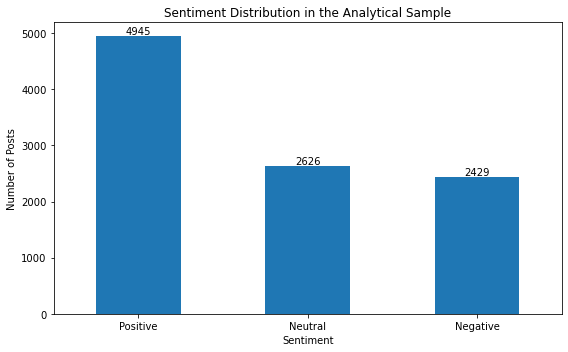

In [58]:
# Sentiment distribution in the final analytical sample
sentiment_order = ["pos", "neu", "neg"]

sentiment_counts = (
    df["sentiment_label"]
    .value_counts()
    .reindex(sentiment_order)
)

sentiment_percent = (
    df["sentiment_label"]
    .value_counts(normalize=True)
    .reindex(sentiment_order)
    * 100
)

sentiment_summary = pd.DataFrame({
    "Count": sentiment_counts,
    "Percentage": sentiment_percent
})

sentiment_summary.index = [
    "Positive",
    "Neutral",
    "Negative"
]

display(sentiment_summary.round(2))

# Visualization
sentiment_counts.index = [
    "Positive",
    "Neutral",
    "Negative"
]

ax = sentiment_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sentiment Distribution in the Analytical Sample")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

**Interpretation.** Positive sentiment represented approximately half of the analytical sample (49.45%), while neutral and negative sentiment represented approximately 26.26% and 24.29%, respectively. The class distribution is moderately imbalanced toward positive sentiment, which was considered during model development and evaluation.

### Temporal Sentiment Patterns

Monthly sentiment proportions were calculated to examine how the relative distribution of positive, neutral, and negative sentiment varied over time. Percentages were calculated within each month to account for differences in monthly posting volume.

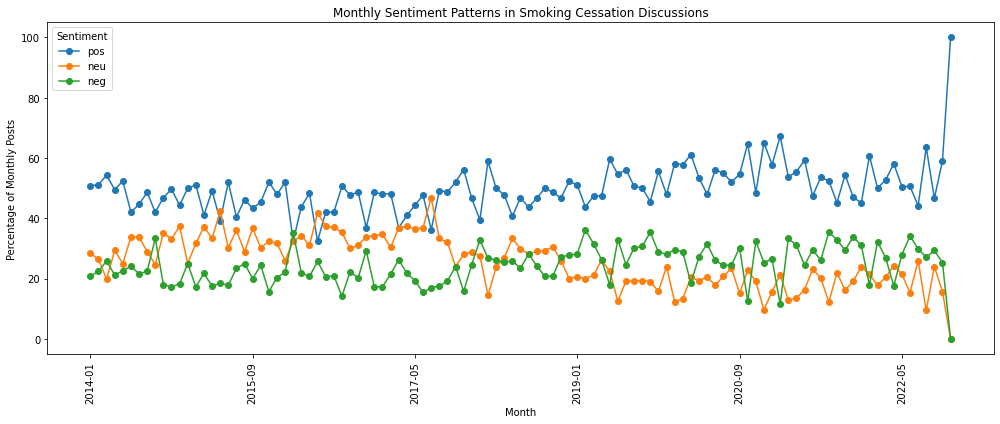

In [24]:
monthly_sentiment = pd.crosstab(
    df["year_month"],
    df["sentiment_label"],
    normalize="index"
) * 100

monthly_sentiment = monthly_sentiment[
    ["pos", "neu", "neg"]
]

monthly_sentiment.plot(
    figsize=(14, 6),
    marker="o"
)

plt.title("Monthly Sentiment Patterns in Smoking Cessation Discussions")
plt.xlabel("Month")
plt.ylabel("Percentage of Monthly Posts")
plt.xticks(rotation=90)
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

**Interpretation.** Monthly sentiment proportions varied over the study period, while positive sentiment generally represented a substantial share of smoking-cessation discussions. Fluctuations across months should be interpreted cautiously because monthly posting volumes may differ and the analytical dataset represents a stratified sample rather than the complete source dataset.

The temporal analysis is descriptive and is intended to characterize changes in the composition of sentiment over time rather than establish causal or population-level trends.

## 6. Engagement Analysis

Social-media engagement variables were highly right-skewed, with many posts receiving no replies, reposts, likes, or quotes. Because median engagement was zero across sentiment groups, engagement was summarized using both mean counts and the percentage of posts receiving at least one interaction.

These results describe associations between sentiment and engagement and should not be interpreted as causal effects.

### Engagement Distribution

Before comparing engagement across sentiment groups, engagement variables were examined for sparsity and distributional characteristics. This diagnostic step was used to determine appropriate summary measures.

In [61]:
# Check engagement data quality

engagement_columns = [
    "replyCount",
    "retweetCount",
    "likeCount",
    "quoteCount"
]

print("Data types:")
print(df[engagement_columns].dtypes)

print("\nSummary statistics:")
display(df[engagement_columns].describe())

print("\nNumber of records with engagement greater than zero:")

for col in engagement_columns:
    nonzero = (df[col] > 0).sum()
    print(f"{col}: {nonzero:,} / {len(df):,}")

print("\nMaximum engagement:")
print(df[engagement_columns].max())



Data types:
replyCount      int64
retweetCount    int64
likeCount       int64
quoteCount      int64
dtype: object

Summary statistics:


,replyCount,retweetCount,likeCount,quoteCount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.404800,0.783900,2.830200,0.066600
std,5.547595,10.159849,34.472752,0.997328
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,0.000000
max,508.000000,538.000000,2353.000000,76.000000



Number of records with engagement greater than zero:
replyCount: 1,967 / 10,000
retweetCount: 1,609 / 10,000
likeCount: 3,817 / 10,000
quoteCount: 317 / 10,000

Maximum engagement:
replyCount       508
retweetCount     538
likeCount       2353
quoteCount        76
dtype: int64


**Interpretation.** Engagement was highly right-skewed. Median replies, retweets, and quotes were zero, while the median number of likes was also zero despite substantially larger maximum values.

Of the 10,000 posts, 1,967 received at least one reply, 1,609 received at least one retweet, 3,817 received at least one like, and 317 received at least one quote. The large differences between typical and maximum engagement indicate that a relatively small number of highly engaged posts influence the mean values.

For this reason, subsequent analyses examine both average engagement and the proportion of posts receiving at least one interaction.

### Mean Engagement by Sentiment

Because engagement counts are highly right-skewed, mean engagement was examined alongside other engagement measures to characterize differences in observed interaction levels across sentiment categories. Mean values should be interpreted cautiously because a small number of highly engaged posts can substantially influence the average.

Mean engagement by sentiment:


,replyCount,retweetCount,likeCount,quoteCount
sentiment_label,,,,
pos,0.375,0.760,2.780,0.053
neu,0.259,0.656,2.086,0.053
neg,0.623,0.972,3.737,0.109


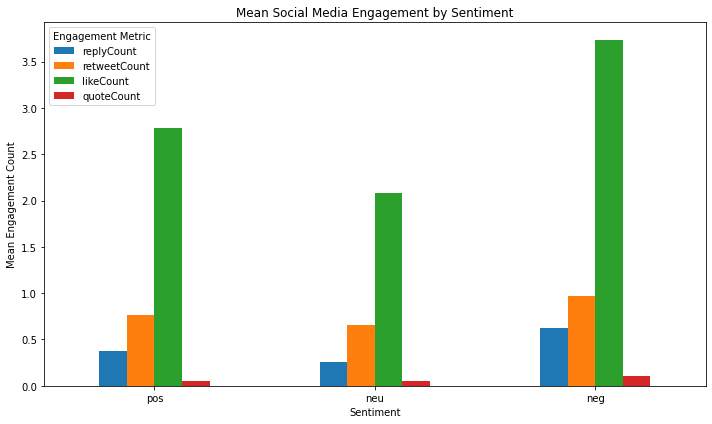

In [62]:

engagement_columns = [
    "replyCount",
    "retweetCount",
    "likeCount",
    "quoteCount"
]

# Calculate mean engagement
mean_engagement = (
    df.groupby("sentiment_label")[engagement_columns]
    .mean()
    .reindex(["pos", "neu", "neg"])
)

print("Mean engagement by sentiment:")
display(mean_engagement.round(3))

mean_engagement.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Mean Social Media Engagement by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Mean Engagement Count")
plt.xticks(rotation=0)
plt.legend(title="Engagement Metric")

plt.tight_layout()
plt.show()

**Interpretation.** Negative-sentiment posts showed the highest mean engagement across all four measures, including replies, retweets, likes, and quotes. Positive-sentiment posts generally showed intermediate mean engagement, while neutral posts showed the lowest mean engagement.

The largest difference was observed for likes, with negative posts averaging approximately 3.74 likes compared with 2.78 for positive posts and 2.09 for neutral posts.

Because engagement distributions are highly right-skewed and the analysis is observational, these differences should be interpreted as descriptive associations rather than evidence that sentiment caused higher or lower engagement.

### Probability of Receiving Engagement

Because a large proportion of posts received zero interactions, engagement was also evaluated as a binary outcome: whether a post received at least one interaction of each type.

This provides a complementary measure to mean engagement that is less dependent on a small number of highly engaged posts.

Percentage of posts with nonzero engagement:


,replyCount,retweetCount,likeCount,quoteCount
sentiment_label,,,,
pos,19.51,17.29,39.72,3.36
neu,16.37,14.20,31.57,2.28
neg,23.55,15.69,42.16,3.75


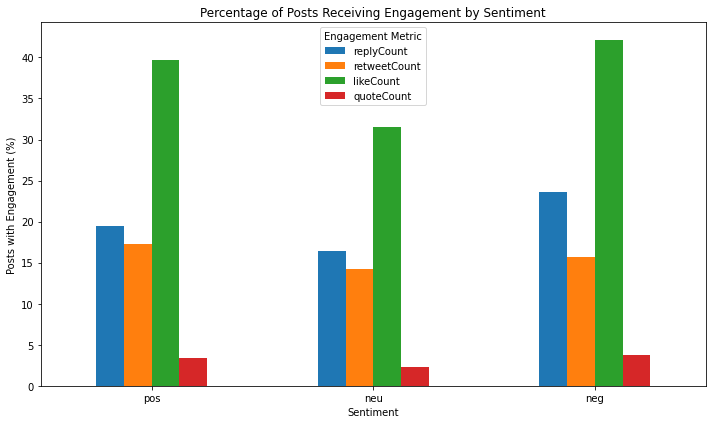

In [63]:
# Calculate percentage of posts with engagement > 0
engagement_rate = (
    df.groupby("sentiment_label")[engagement_columns]
    .apply(lambda x: (x > 0).mean() * 100)
    .reindex(["pos", "neu", "neg"])
)

print("Percentage of posts with nonzero engagement:")
display(engagement_rate.round(2))

engagement_rate.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Percentage of Posts Receiving Engagement by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Posts with Engagement (%)")
plt.xticks(rotation=0)
plt.legend(title="Engagement Metric")

plt.tight_layout()
plt.show()

**Interpretation.** Negative-sentiment posts were more likely to receive at least one reply, like, or quote than positive or neutral posts. Approximately 23.55% of negative posts received a reply and 42.16% received at least one like.

Positive-sentiment posts showed a slightly higher probability of receiving at least one retweet (17.29%) than negative (15.69%) or neutral posts (14.20%). Neutral posts generally showed the lowest observed engagement rates.

Together with the mean-engagement results, these findings suggest an association between sentiment category and observed engagement patterns. However, this analysis is descriptive and does not establish that sentiment caused differences in engagement.

Percentage of posts with nonzero engagement:


,replyCount,retweetCount,likeCount,quoteCount
sentiment_label,,,,
pos,19.52,17.29,39.72,3.36
neu,16.38,14.21,31.58,2.29
neg,23.55,15.69,42.16,3.75


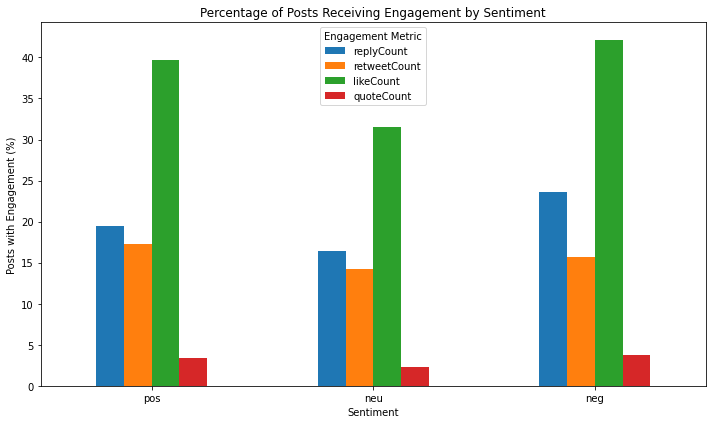

In [28]:
# Calculate percentage of posts with engagement > 0
engagement_rate = (
    df.groupby("sentiment_label")[engagement_columns]
    .apply(lambda x: (x > 0).mean() * 100)
    .reindex(["pos", "neu", "neg"])
)

print("Percentage of posts with nonzero engagement:")
display(engagement_rate.round(2))

engagement_rate.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Percentage of Posts Receiving Engagement by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Posts with Engagement (%)")
plt.xticks(rotation=0)
plt.legend(title="Engagement Metric")

plt.tight_layout()
plt.show()

### Distribution of Likes by Sentiment

Like counts were strongly right-skewed, with a small number of posts receiving substantially higher engagement than most observations. A `log(1 + x)` transformation was therefore applied to improve visualization while retaining posts with zero likes.

The transformed distribution was compared across sentiment categories using boxplots.

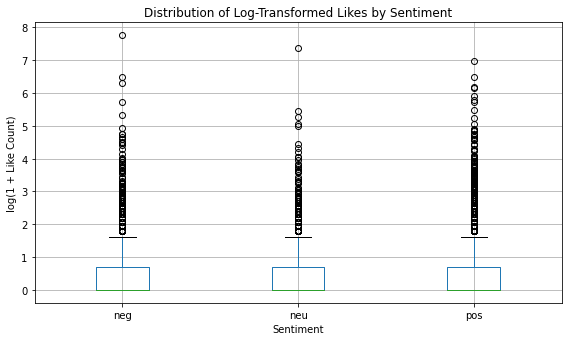

In [64]:

df["log_likes"] = np.log1p(df["likeCount"])

df.boxplot(
    column="log_likes",
    by="sentiment_label",
    figsize=(8, 5)
)

plt.title("Distribution of Log-Transformed Likes by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Like Count)")

plt.tight_layout()
plt.show()

**Interpretation.** The log-transformed like distributions show substantial variability within each sentiment category. The transformation reduces the visual influence of extremely highly liked posts while retaining observations with zero likes.

Negative-sentiment posts showed somewhat higher observed like engagement, consistent with the mean and nonzero-engagement analyses. However, substantial overlap remains among the sentiment groups, indicating that sentiment category alone does not determine the level of engagement a post receives.

These patterns are descriptive associations and should not be interpreted as causal effects.

## 7. Text and Term-Frequency Analysis

Term-frequency analysis was used to identify recurring language in the smoking-cessation corpus. Because highly frequent domain terms such as "smoking" and "quit" provide limited discriminatory information, an initial frequency analysis was followed by removal of common domain-specific terms and obvious text-processing artifacts.

Top 25 most frequent terms:


,word,frequency
0,quit,7938
1,smoke,5221
2,smoking,4144
3,cigarette,958
4,help,898
5,day,577
6,like,576
7,try,560
8,want,537
9,amp,522


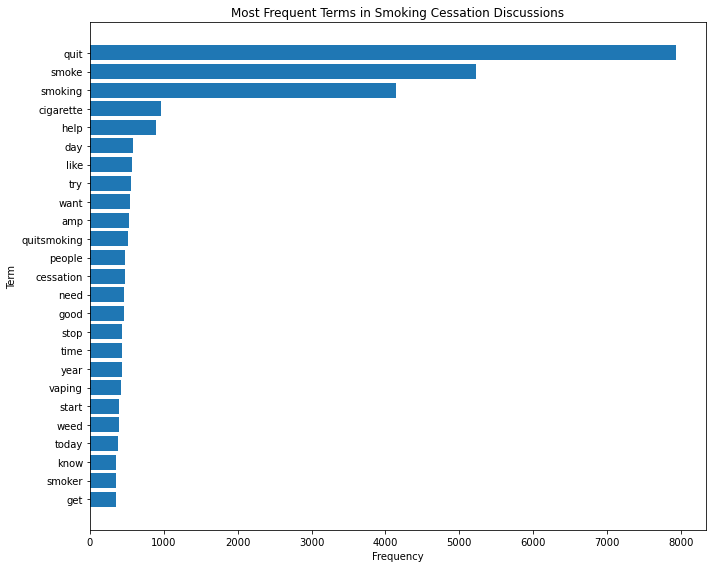

In [65]:

# Combine all lemmatized text
text = " ".join(
    df["lemmatized_sentence"]
    .dropna()
    .astype(str)
)

# Split into tokens
tokens = text.split()

# Remove very short tokens
tokens = [
    word.lower()
    for word in tokens
    if len(word) > 2
]

word_counts = Counter(tokens)

top_words = pd.DataFrame(
    word_counts.most_common(25),
    columns=["word", "frequency"]
)

print("Top 25 most frequent terms:")
display(top_words)

# Plot
plot_data = top_words.sort_values("frequency")

plt.figure(figsize=(10, 8))
plt.barh(
    plot_data["word"],
    plot_data["frequency"]
)

plt.title("Most Frequent Terms in Smoking Cessation Discussions")
plt.xlabel("Frequency")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

**Interpretation.** The initial frequency analysis was dominated by expected domain terms such as "quit," "smoke," and "smoking." The token "amp" also appeared frequently and was treated as a text-processing artifact. Because these terms provide limited thematic differentiation, they were removed from the subsequent descriptive term-frequency analysis.

Top informative terms after removing dominant query terms:


,term,frequency
0,cigarette,958
1,help,898
2,day,577
3,like,576
4,try,560
5,want,537
6,people,480
7,need,463
8,good,458
9,stop,435



Top informative terms — POS
help                      745
cigarette                 442
like                      411
good                      365
want                      365
day                       311
try                       274
free                      272
people                    236
year                      225
time                      223
vaping                    221
need                      214
stop                      210
start                     201

Top informative terms — NEU
cigarette                 221
day                       130
weed                      117
need                      112
try                       108
today                     100
think                     80
gum                       79
time                      78
vaping                    76
start                     75
year                      75
people                    72
tobacco                   68
new                       66

Top informative terms — NEG
cigarette             

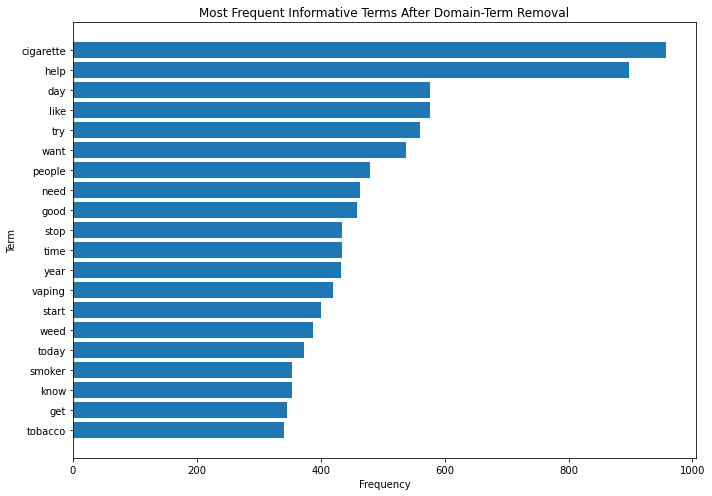

In [68]:


# Terms that dominate because of dataset selection/query
domain_stopwords = {
    "quit",
    "smoke",
    "smoking",
    "quitsmoking",
    "cessation",
    "amp"
}

def informative_terms(data, sentiment=None, n=20):
    
    if sentiment is not None:
        text_series = data.loc[
            data["sentiment_label"] == sentiment,
            "lemmatized_sentence"
        ]
    else:
        text_series = data["lemmatized_sentence"]

    text = " ".join(
        text_series.dropna().astype(str)
    )

    tokens = [
        word.lower()
        for word in text.split()
        if len(word) > 2
        and word.lower() not in domain_stopwords
    ]

    return Counter(tokens).most_common(n)


# Overall informative terms
overall_terms = informative_terms(df, n=20)

overall_df = pd.DataFrame(
    overall_terms,
    columns=["term", "frequency"]
)

print("Top informative terms after removing dominant query terms:")
display(overall_df)

# Sentiment-specific terms
for sentiment in ["pos", "neu", "neg"]:
    print(f"\nTop informative terms — {sentiment.upper()}")
    
    for term, frequency in informative_terms(
        df,
        sentiment=sentiment,
        n=15
    ):
        print(f"{term:<25} {frequency}")
        
    # Visualize overall informative terms
plot_data = overall_df.sort_values("frequency")

plt.figure(figsize=(10, 7))
plt.barh(
    plot_data["term"],
    plot_data["frequency"]
)

plt.title("Most Frequent Informative Terms After Domain-Term Removal")
plt.xlabel("Frequency")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

**Interpretation.** After removing dominant smoking-cessation query terms and the "amp" text-processing artifact, the remaining vocabulary provided greater thematic differentiation. Frequently occurring terms included "cigarette," "help," "day," "like," "try," "want," "people," and "need."

Sentiment-specific frequencies showed partially distinct patterns. Positive posts frequently contained terms such as "help," "good," and "free," while negative posts included terms such as "bad" and "stop." Neutral posts contained more descriptive terms related to smoking and cessation behaviors, including "gum" and "tobacco."

Substantial vocabulary overlap remained across the three sentiment categories. This suggests that individual word frequencies alone provide limited information for distinguishing sentiment and supports the use of multivariate text representations and supervised classification in the subsequent analysis.

## 8. TF-IDF Feature Engineering

The lemmatized post text was used as the input for supervised sentiment classification. The dataset was divided into training (80%) and testing (20%) subsets using stratified sampling to preserve the sentiment-class distribution.

TF-IDF features included unigrams and bigrams. English stop words were removed, very rare terms were excluded, and sublinear term-frequency scaling was applied.

> **Evaluation note:** The classifiers were evaluated against the existing sentiment labels contained in the dataset. Results therefore represent agreement with the dataset's labeling framework rather than accuracy against independently adjudicated human sentiment.

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -------------------------------------------------------
# 1. Prepare modeling dataset
# -------------------------------------------------------

model_df = df[
    ["lemmatized_sentence", "sentiment_label"]
].dropna().copy()

model_df = model_df[
    model_df["sentiment_label"].isin(["pos", "neu", "neg"])
]

X = model_df["lemmatized_sentence"]
y = model_df["sentiment_label"]

print("Modeling records:", len(model_df))

print("\nTarget distribution:")
print(y.value_counts())

# -------------------------------------------------------
# 2. Stratified train/test split
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))

# -------------------------------------------------------
# 3. TF-IDF
# -------------------------------------------------------

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=15000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF training matrix:")
print(X_train_tfidf.shape)

print("TF-IDF testing matrix:")
print(X_test_tfidf.shape)



Modeling records: 10000

Target distribution:
pos    4945
neu    2626
neg    2429
Name: sentiment_label, dtype: int64

Training records: 8000
Testing records: 2000

TF-IDF training matrix:
(8000, 5125)
TF-IDF testing matrix:
(2000, 5125)


**Result.** All 10,000 validated observations were retained for modeling. The stratified 80/20 split produced 8,000 training observations and 2,000 test observations while preserving the sentiment-class distribution.

The fitted TF-IDF representation contained **5,125 unigram and bigram features** after applying the specified frequency thresholds and feature-selection parameters.

## 9. Logistic Regression

A multiclass Logistic Regression classifier was trained using the TF-IDF features. Balanced class weights were used to reduce the influence of the moderately imbalanced sentiment distribution.

Performance was evaluated using accuracy, class-specific precision, recall, F1-score, and a confusion matrix.

In [70]:
# Train Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

# Generate predictions
y_pred_lr = logistic_model.predict(X_test_tfidf)

# Evaluate model
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print(f"\nAccuracy: {accuracy_lr:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        digits=4
    )
)

LOGISTIC REGRESSION RESULTS

Accuracy: 0.6845

Classification Report:
              precision    recall  f1-score   support

         neg     0.5793    0.6091    0.5938       486
         neu     0.5911    0.7352    0.6553       525
         pos     0.8218    0.6946    0.7529       989

    accuracy                         0.6845      2000
   macro avg     0.6640    0.6796    0.6673      2000
weighted avg     0.7023    0.6845    0.6886      2000



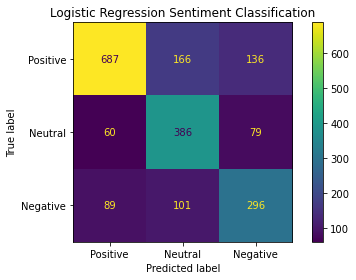

In [71]:
# Confusion matrix for Logistic Regression
class_order = ["pos", "neu", "neg"]

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Positive", "Neutral", "Negative"]
)

disp.plot(values_format="d")

plt.title("Logistic Regression Sentiment Classification")
plt.tight_layout()
plt.show()

**Interpretation.** Logistic Regression achieved an overall accuracy of **68.45%** on the 2,000-observation held-out test set. Performance was strongest for positive sentiment (F1 = 0.7529), followed by neutral (F1 = 0.6553) and negative sentiment (F1 = 0.5938).

The confusion matrix shows that 687 positive, 386 neutral, and 296 negative observations were correctly classified. The largest individual misclassification pattern involved positive observations predicted as neutral (166 cases), followed by positive observations predicted as negative (136 cases).

Although the model demonstrated meaningful agreement with the existing sentiment labels, performance varied across classes. Because the reference labels were already present in the source dataset rather than independently adjudicated human annotations, these results should be interpreted as agreement with the dataset's labeling framework rather than accuracy against verified human sentiment.

## 10. Multinomial Naive Bayes

Multinomial Naive Bayes was evaluated as a second text-classification approach using the same TF-IDF training and test matrices.

Using identical train/test partitions allows the models to be compared on the same observations. Model performance was evaluated using accuracy, precision, recall, F1-score, and the confusion matrix.

In [73]:


nb_model = MultinomialNB(alpha=0.5)

nb_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = nb_model.predict(
    X_test_tfidf
)

accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

print("MULTINOMIAL NAIVE BAYES RESULTS")
print("=" * 50)

print(f"\nAccuracy: {accuracy_nb:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb,
        digits=4
    )
)

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["pos", "neu", "neg"]
)



MULTINOMIAL NAIVE BAYES RESULTS

Accuracy: 0.6550

Classification Report:
              precision    recall  f1-score   support

         neg     0.6982    0.3951    0.5046       486
         neu     0.6800    0.4857    0.5667       525
         pos     0.6393    0.8726    0.7379       989

    accuracy                         0.6550      2000
   macro avg     0.6725    0.5845    0.6031      2000
weighted avg     0.6643    0.6550    0.6363      2000



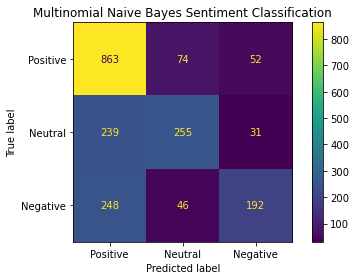

In [74]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Positive", "Neutral", "Negative"]
)

disp.plot(values_format="d")

plt.title("Multinomial Naive Bayes Sentiment Classification")
plt.tight_layout()
plt.show()

**Interpretation.** Multinomial Naive Bayes achieved an overall accuracy of **65.50%** on the 2,000-observation held-out test set. Performance was strongest for positive sentiment (F1 = 0.7379), followed by neutral (F1 = 0.5667) and negative sentiment (F1 = 0.5046).

The confusion matrix shows that 863 positive, 255 neutral, and 192 negative observations were correctly classified. The largest individual misclassification patterns involved negative observations predicted as positive (248 cases) and neutral observations predicted as positive (239 cases).

Positive sentiment achieved high recall (0.8726), whereas recall was substantially lower for neutral (0.4857) and negative sentiment (0.3951). This indicates that Multinomial Naive Bayes tended to favor the positive class and was less effective at identifying neutral and negative observations.

As with Logistic Regression, these results represent agreement with the existing dataset labels rather than accuracy against independently adjudicated human sentiment.

## 11. Model Comparison

Logistic Regression and Multinomial Naive Bayes were evaluated on the same held-out test set. In addition to overall accuracy, macro-averaged precision, recall, and F1-score were examined because the sentiment classes were not perfectly balanced.

Weighted F1-score was also calculated to summarize performance while accounting for class frequencies.

In [76]:


results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb)
    ],
    
    "Macro Precision": [
        precision_score(
            y_test, y_pred_lr,
            average="macro"
        ),
        precision_score(
            y_test, y_pred_nb,
            average="macro"
        )
    ],
    
    "Macro Recall": [
        recall_score(
            y_test, y_pred_lr,
            average="macro"
        ),
        recall_score(
            y_test, y_pred_nb,
            average="macro"
        )
    ],
    
    "Macro F1": [
        f1_score(
            y_test, y_pred_lr,
            average="macro"
        ),
        f1_score(
            y_test, y_pred_nb,
            average="macro"
        )
    ],
    
    "Weighted F1": [
        f1_score(
            y_test, y_pred_lr,
            average="weighted"
        ),
        f1_score(
            y_test, y_pred_nb,
            average="weighted"
        )
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,0.6845,0.6640,0.6796,0.6673,0.6886
1,Multinomial Naive Bayes,0.6550,0.6725,0.5845,0.6031,0.6363


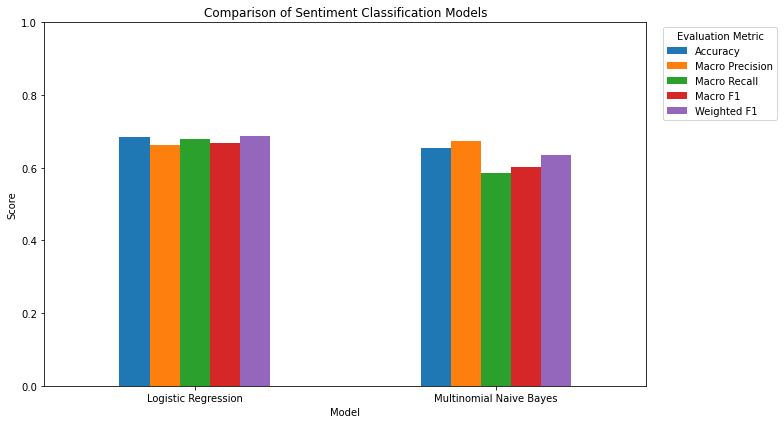

In [77]:
# Visual comparison of model performance
plot_results = results.set_index("Model")[
    ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]
]

plot_results.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparison of Sentiment Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Interpretation.** Logistic Regression achieved higher overall accuracy (0.6845) than Multinomial Naive Bayes (0.6550). Logistic Regression also produced higher macro recall (0.6796 vs. 0.5845), macro F1-score (0.6673 vs. 0.6031), and weighted F1-score (0.6886 vs. 0.6363).

Multinomial Naive Bayes produced slightly higher macro precision (0.6725 vs. 0.6640), but its substantially lower macro recall reflects weaker identification of the neutral and negative classes.

Overall, Logistic Regression demonstrated more balanced performance across the three sentiment categories and was therefore carried forward for detailed error analysis and model interpretation.

These comparisons represent agreement with the dataset's existing sentiment labels rather than performance against independently adjudicated human sentiment.

## 12. Error Analysis

To better understand model limitations, Logistic Regression predictions were compared with the existing sentiment labels in the held-out test set. Misclassifications were summarized by actual and predicted class.

Individual source posts are not displayed in the public notebook to minimize redistribution of social-media content.

In [78]:
error_analysis = pd.DataFrame({
    "actual": y_test.reset_index(drop=True),
    "predicted": pd.Series(y_pred_lr)
})

errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
].copy()

print(
    "Correct predictions:",
    (error_analysis["actual"] == error_analysis["predicted"]).sum()
)

print(
    "Misclassified:",
    len(errors)
)

print("\nMisclassification patterns:")

error_patterns = pd.crosstab(
    errors["actual"],
    errors["predicted"]
)

display(error_patterns)

Correct predictions: 1369
Misclassified: 631

Misclassification patterns:


predicted,neg,neu,pos
actual,,,
neg,0,101,89
neu,79,0,60
pos,136,166,0


**Interpretation.** Logistic Regression produced 631 disagreements with the existing sentiment labels in the 2,000-observation test set, corresponding to 1,369 correct classifications.

The most frequent disagreement involved positive observations classified as neutral (166 cases), followed by positive observations classified as negative (136 cases). Negative observations were classified as neutral in 101 cases and as positive in 89 cases. Neutral observations were classified as negative in 79 cases and as positive in 60 cases.

These patterns indicate that classification errors occurred across all three sentiment categories rather than being concentrated in a single pair of classes. Informal social-media language, short or context-dependent expressions, slang, mixed sentiment, and other linguistic ambiguity may contribute to classification difficulty. In addition, some apparent model errors may reflect uncertainty or noise in the dataset's existing sentiment labels.

Because the reference labels were not independently adjudicated human annotations, these cases are interpreted as model-label disagreements rather than definitive classification errors.

## 13. Model Interpretability

To examine how the Logistic Regression classifier differentiated sentiment categories, the largest positive coefficients for each class were extracted.

In a multiclass Logistic Regression model, features with larger positive coefficients provide stronger evidence for the corresponding class, conditional on the other features represented in the model.

These coefficients represent predictive associations learned from the training data and should not be interpreted as causal relationships.

In [79]:
import numpy as np
import pandas as pd

# Compatibility with older scikit-learn versions
try:
    feature_names = np.array(
        tfidf.get_feature_names_out()
    )
except AttributeError:
    feature_names = np.array(
        tfidf.get_feature_names()
    )

classes = logistic_model.classes_

print("Model classes:")
print(classes)

print("\nNumber of TF-IDF features:")
print(len(feature_names))

top_features = {}

for i, sentiment in enumerate(classes):

    coefficients = logistic_model.coef_[i]

    top_indices = np.argsort(
        coefficients
    )[-20:][::-1]

    top_features[sentiment] = pd.DataFrame({
        "feature": feature_names[top_indices],
        "coefficient": coefficients[top_indices]
    })

    print(
        f"\nTop features associated with "
        f"{sentiment.upper()} sentiment:"
    )

    display(
        top_features[sentiment]
    )

Model classes:
['neg' 'neu' 'pos']

Number of TF-IDF features:
5125

Top features associated with NEG sentiment:


,feature,coefficient
0,bad,4.064732
1,shit,3.425811
2,stop,3.282695
3,cancer,3.253244
4,fuck,3.073405
5,kill,3.017617
6,lung_cancer,2.834517
7,die,2.743661
8,hate,2.538543
9,death,2.400431



Top features associated with NEU sentiment:


,feature,coefficient
0,quitsmoking,1.727482
1,smoking,1.547219
2,smoke,1.440277
3,hypnosis,1.438646
4,what_happens,1.392881
5,quit smoking,1.314713
6,weed,1.267929
7,today quit,1.146336
8,weed amp,1.142589
9,cessation,1.127642



Top features associated with POS sentiment:


,feature,coefficient
0,help,3.711134
1,free,3.660553
2,love,3.539822
3,good,3.531675
4,like,3.140155
5,great,3.017133
6,lol,2.935933
7,support,2.864810
8,best,2.686062
9,happy,2.516133


**Interpretation.** The Logistic Regression coefficients revealed distinct linguistic patterns associated with each sentiment category.

Negative sentiment was strongly associated with terms such as *bad*, *cancer*, *kill*, *lung_cancer*, *death*, *stress*, *difficult*, and *risk*. These features reflect language related to health consequences, difficulty, distress, and other adverse experiences. Several strongly weighted negative features also contained profanity, illustrating the informal language present in social-media discussions.

Neutral sentiment was more strongly associated with topic-oriented terms and phrases such as *quitsmoking*, *smoking*, *smoke*, *hypnosis*, *quit smoking*, *cessation*, and *gum*. Compared with the other classes, these features appear more descriptive of the smoking-cessation topic itself rather than clearly expressing positive or negative affect.

Positive sentiment was associated with terms such as *help*, *free*, *love*, *good*, *great*, *support*, *happy*, *care*, *healthy*, *hope*, *success*, and *proud*. These features suggest supportive, encouraging, and health-oriented language within positive smoking-cessation discussions.

The coefficients represent predictive associations within the fitted model. They should not be interpreted as causal effects or as estimates of how important these terms are in the broader population of smoking-cessation discussions.

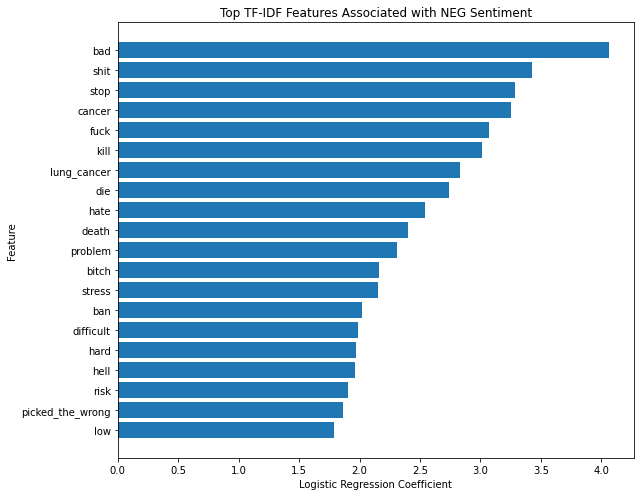

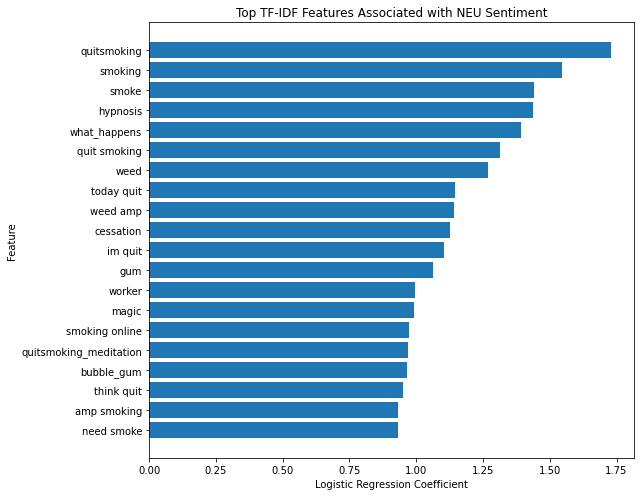

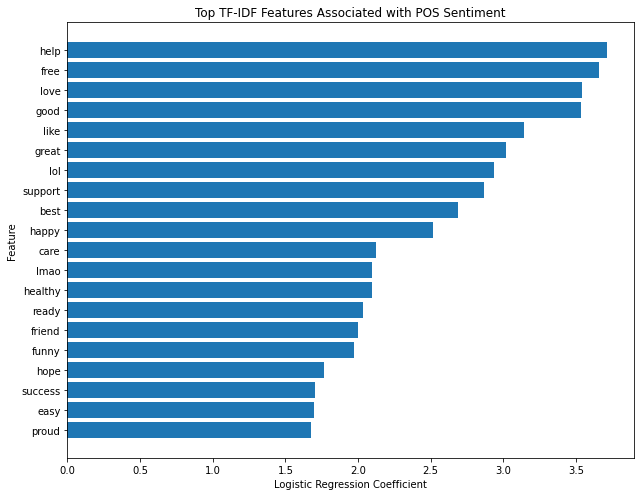

In [81]:
for sentiment in classes:

    feature_df = (
        top_features[sentiment]
        .sort_values("coefficient")
    )

    plt.figure(figsize=(9, 7))

    plt.barh(
        feature_df["feature"],
        feature_df["coefficient"]
    )

    plt.title(
        f"Top TF-IDF Features Associated with "
        f"{sentiment.upper()} Sentiment"
    )

    plt.xlabel(
        "Logistic Regression Coefficient"
    )

    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


## 14. Public-Health Context

### COVID-Related Discussions

An existing COVID indicator was examined as an exploratory contextual variable. Before comparing sentiment patterns, the prevalence of COVID-related observations was assessed to determine the size of the relevant subgroup.

Because COVID-related posts represent only a small proportion of the analytical sample, subsequent comparisons should be interpreted as exploratory rather than as evidence of population-level or causal differences.

In [82]:
# Check COVID variable first

print("COVID indicator distribution:")
print(df["COVID"].value_counts(dropna=False))

print("\nPercentage:")
print(
    (
        df["COVID"]
        .value_counts(normalize=True, dropna=False)
        * 100
    ).round(2)
)

COVID indicator distribution:
False    9866
True      134
Name: COVID, dtype: int64

Percentage:
False    98.66
True      1.34
Name: COVID, dtype: float64


Sentiment distribution by COVID indicator:


sentiment_label,pos,neu,neg
COVID,,,
Not COVID-related,49.19,26.51,24.31
COVID-related,68.66,8.21,23.13


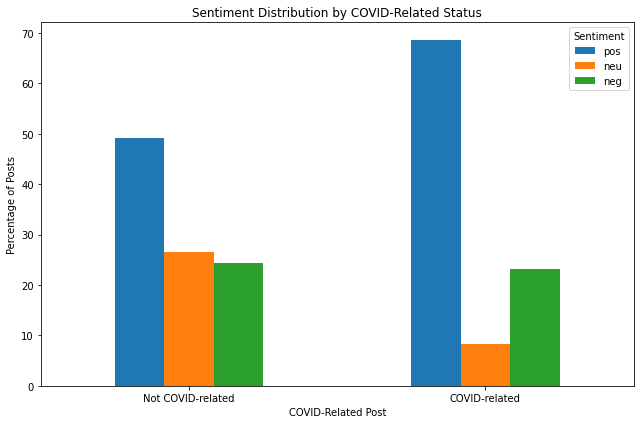

In [84]:
covid_sentiment = pd.crosstab(
    df["COVID"],
    df["sentiment_label"],
    normalize="index"
) * 100

covid_sentiment = covid_sentiment[
    ["pos", "neu", "neg"]
]
covid_sentiment.index = covid_sentiment.index.map({
    False: "Not COVID-related",
    True: "COVID-related"
})

print("Sentiment distribution by COVID indicator:")
display(covid_sentiment.round(2))

covid_sentiment.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title(
    "Sentiment Distribution by COVID-Related Status"
)

plt.xlabel("COVID-Related Post")
plt.ylabel("Percentage of Posts")

plt.xticks(
    rotation=0
)

plt.legend(
    title="Sentiment"
)

plt.tight_layout()
plt.show()

**Interpretation.** COVID-related observations represented only 134 posts (1.34%) of the 10,000-record analytical sample, compared with 9,866 posts (98.66%) that were not identified as COVID-related.

Within this small COVID-related subgroup, 68.66% of observations were labeled positive, 23.13% negative, and 8.21% neutral. Among non-COVID-related observations, the corresponding proportions were 49.19% positive, 24.31% negative, and 26.51% neutral.

The COVID-related subgroup therefore showed a higher proportion of positive sentiment and a lower proportion of neutral sentiment in this analytical sample. However, because the COVID-related subgroup contained only 134 observations and the analysis is descriptive, these differences should not be interpreted as evidence that COVID-related discussion caused changes in sentiment or as population-level estimates.

In [41]:


# Compatibility with older scikit-learn versions
try:
    feature_names = np.array(
        tfidf.get_feature_names_out()
    )
except AttributeError:
    feature_names = np.array(
        tfidf.get_feature_names()
    )

classes = logistic_model.classes_

print("Model classes:")
print(classes)

print("\nNumber of TF-IDF features:")
print(len(feature_names))

top_features = {}

for i, sentiment in enumerate(classes):

    coefficients = logistic_model.coef_[i]

    top_indices = np.argsort(
        coefficients
    )[-20:][::-1]

    top_features[sentiment] = pd.DataFrame({
        "feature": feature_names[top_indices],
        "coefficient": coefficients[top_indices]
    })

    print(
        f"\nTop features associated with "
        f"{sentiment.upper()} sentiment:"
    )

    display(
        top_features[sentiment]
    )

Model classes:
['neg' 'neu' 'pos']

Number of TF-IDF features:
5097

Top features associated with NEG sentiment:


,feature,coefficient
0,bad,4.096894
1,cancer,3.358628
2,shit,3.318074
3,stop,3.260044
4,kill,3.136288
5,fuck,3.018925
6,lung_cancer,2.841520
7,die,2.690017
8,hate,2.431709
9,death,2.341708



Top features associated with NEU sentiment:


,feature,coefficient
0,quitsmoking,1.771671
1,smoking,1.685231
2,smoke,1.482782
3,hypnosis,1.406354
4,what_happens,1.352838
5,weed,1.182994
6,quit smoking,1.133077
7,today quit,1.098939
8,quitsmoking_meditation,1.071705
9,gum,1.059984



Top features associated with POS sentiment:


,feature,coefficient
0,free,3.827885
1,help,3.704225
2,love,3.478000
3,good,3.402896
4,like,3.202866
5,lol,3.024843
6,support,2.983459
7,great,2.982244
8,best,2.725423
9,happy,2.463918


## 15. Limitations

Several limitations should be considered when interpreting this analysis.

1. **Reference labels:** The supervised classifiers were evaluated against sentiment labels already contained in the source dataset. These labels were not independently adjudicated human annotations. Model performance therefore represents agreement with the existing labeling framework rather than accuracy against verified human sentiment.

2. **Sampling:** The analytical dataset contains 10,000 observations sampled from a substantially larger source dataset. Although stratified sampling was used to preserve the source sentiment distribution, the sample may not capture every linguistic or temporal pattern present in the full dataset.

3. **Text representation and preprocessing:** TF-IDF provides an interpretable representation of word and phrase usage but does not fully capture contextual meaning, sarcasm, mixed sentiment, emojis, or complex linguistic relationships. Some residual text-processing artifacts, including features containing `amp`, also remained in the vocabulary.

4. **Social-media language:** Short posts, slang, profanity, humor, and context-dependent expressions can make sentiment classification difficult and may contribute to model-label disagreement.

5. **Engagement data:** Replies, reposts, likes, and quotes were highly right-skewed, with many posts receiving no engagement. Observed associations between sentiment and engagement should not be interpreted as causal relationships.

6. **Platform representation:** Social-media users are not necessarily representative of the broader population of people who smoke, attempt cessation, or receive smoking-cessation treatment.

7. **COVID subgroup:** Only 134 observations (1.34% of the analytical sample) were identified as COVID-related. Comparisons involving this subgroup are exploratory and should be interpreted cautiously.

8. **Data governance:** Raw social-media identifiers and source records are not distributed through this repository. Public outputs emphasize aggregate results to reduce unnecessary redistribution of individual social-media content.

## 16. Conclusions

This project demonstrated an end-to-end NLP and machine-learning workflow for analyzing sentiment in public smoking-cessation discussions using a stratified analytical sample of 10,000 social-media observations.

Positive sentiment represented approximately half of the analytical sample, while neutral and negative sentiment accounted for the remainder. Engagement analysis identified descriptive differences across sentiment categories, with negative-sentiment posts showing higher observed engagement on several measures.

TF-IDF-based classification demonstrated that conventional machine-learning methods can identify meaningful sentiment-associated linguistic patterns. Logistic Regression achieved 68.45% accuracy and showed more balanced performance across sentiment categories than Multinomial Naive Bayes on the held-out test set.

Model interpretation revealed substantively meaningful linguistic patterns. Negative classifications were associated with terms involving cancer, lung cancer, risk, death, stress, and difficulty, whereas positive classifications were associated with help, support, health, care, hope, and success. Neutral classifications were more strongly associated with descriptive smoking-cessation terminology.

Error analysis also demonstrated important limitations of automated sentiment classification. Informal language, contextual ambiguity, mixed sentiment, residual preprocessing artifacts, and potentially noisy reference labels can contribute to disagreement between model predictions and existing sentiment labels.

The exploratory COVID analysis identified differences in sentiment composition within a small COVID-related subgroup; however, the limited subgroup size prevents population-level or causal interpretation.

Overall, the project illustrates how NLP can be used to characterize large-scale public-health conversations while emphasizing reproducible analysis, transparent model evaluation, responsible interpretation, and data governance.